# MIOM Capstone — Deep Learning Engine (N-CMAPSS DS02)
## CNN-LSTM RUL Prediction Pipeline | Kaggle H100

**Pipeline Overview:**
1. Install deps + kgout (auto-sync outputs to Drive)
2. Load & explore N-CMAPSS DS02
3. Train/Test split + Normalisation
4. Sliding-window dataset construction
5. CNN-LSTM model definition
6. Training loop with per-epoch checkpointing
7. Evaluation — RMSE + Asymmetric Score
8. Export: best_model.pt + scaler.pkl + inference.py

---
**Dataset:** Add `N-CMAPSS_DS02-006.h5` from Kaggle dataset to this notebook's inputs.  
**kgout:** Add your `kgout_token.json` (or service account JSON) as a private Kaggle dataset named `kgout-credentials`.  
Replace `YOUR_GDRIVE_FOLDER_ID` below before running.

---
## Cell 1 — Install Dependencies

In [1]:
# ── Install all required packages ──────────────────────────────────────────────
!pip install kgout[gdrive] -q
!pip install joblib scikit-learn -q  # already present on Kaggle but explicit is safer

print("✅ Dependencies installed")

✅ Dependencies installed


---
## Cell 2 — kgout Setup (Auto-Sync to Google Drive)

**Before running:** 
- Set your `GDRIVE_FOLDER_ID` below (copy from your Drive folder URL).
- Make sure your `kgout-credentials` dataset is attached to this notebook.

kgout will watch `/kaggle/working/` and automatically upload every new file the moment it's saved — including checkpoints after each epoch.

In [2]:
import os
from kgout import KgOut

# ── CONFIGURE THESE ────────────────────────────────────────────────────────────
GDRIVE_FOLDER_ID  = "1A5FDlOjaoZdw9t6uYPmTUUnD2ryjW843"           # e.g. '1aBcDeFgHiJkLmNoPqRsTuVwXyZ'
KGOUT_CREDENTIALS = "/kaggle/input/datasets/aditivy/kgout-token/kgout_token.json"  # OAuth2 token
# If using a service account instead:
# KGOUT_CREDENTIALS = "/kaggle/input/kgout-credentials/service_account.json"
# ──────────────────────────────────────────────────────────────────────────────

kg = KgOut(
    folder_id=GDRIVE_FOLDER_ID,
    credentials=KGOUT_CREDENTIALS,
    interval=30,           # scan every 30 seconds
    verbose=True,
).start()

print("✅ kgout running — all files saved to /kaggle/working/ will auto-sync to Drive")

[kgout 08:08:03] 🔑 Using OAuth2 user credentials
[kgout 08:08:03] ☁️  Google Drive connected → folder 1A5FDlOjaoZdw9t6uYPmTUUnD2ryjW843
[kgout 08:08:03] 📸 Snapshot: 0 existing file(s) in '/kaggle/working'
[kgout 08:08:03] 👀 kgout watching '/kaggle/working' every 30s → gdrive
✅ kgout running — all files saved to /kaggle/working/ will auto-sync to Drive


---
## Cell 3 — Imports & Global Config

In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time
import math
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# ── PATHS ──────────────────────────────────────────────────────────────────────
# Pointing directly to the attached 'aircraft' dataset by shreyaravi0
H5_PATH   = "/kaggle/input/datasets/chaturvedivybhav/aircraft-ds02-006/N-CMAPSS_DS02-006.h5"
OUT_DIR   = Path("/kaggle/working")
OUT_DIR.mkdir(exist_ok=True)

# ── TRAINING CONFIG ────────────────────────────────────────────────────────────
CONFIG = {
    # Data
    "sampling"       : 1,     # ← set to 1 for full 1Hz run after pipeline validation
    "window"         : 50,     # sliding window length (time-steps)
    "stride"         : 1,      # window stride
    "n_features"     : 18,     # 4 (W) + 14 (X_s)

    # Model
    "cnn_filters"    : 64,
    "lstm_hidden"    : 128,
    "lstm_layers"    : 2,
    "dropout"        : 0.4,

    # Training
    "batch_size"     : 512,
    "lr"             : 2e-4,
    "epochs"         : 80,
    "patience"       : 20,     # early stopping patience
    "lr_patience"    : 8,      # ReduceLROnPlateau patience
    "lr_factor"      : 0.5,

    # Train/Test split (published DS02 protocol)
    "train_units"    : [2, 5, 10, 16, 18, 20],
    "test_units"     : [11, 14, 15],
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"\n📋 CONFIG:")
for k, v in CONFIG.items():
    print(f"   {k:<20} = {v}")

✅ Device: cuda
   GPU: NVIDIA H100 80GB HBM3
   VRAM: 85.0 GB

📋 CONFIG:
   sampling             = 1
   window               = 50
   stride               = 1
   n_features           = 18
   cnn_filters          = 64
   lstm_hidden          = 128
   lstm_layers          = 2
   dropout              = 0.4
   batch_size           = 512
   lr                   = 0.0002
   epochs               = 80
   patience             = 20
   lr_patience          = 8
   lr_factor            = 0.5
   train_units          = [2, 5, 10, 16, 18, 20]
   test_units           = [11, 14, 15]


---
## Cell 4 — Load & Explore N-CMAPSS DS02

In [4]:
print("📂 Loading N-CMAPSS DS02...")
t0 = time.time()

with h5py.File(H5_PATH, 'r') as f:
    print("HDF5 keys found:", list(f.keys()))

    # ── This dataset uses _dev / _test / _var suffixes ──────────────────────
    # _dev  = development/training data  (our train set)
    # _test = test data                  (our test set)
    # _var  = validation split (no Y labels — we skip it)

    # Training arrays
    W_tr  = np.array(f['W_dev'],     dtype=np.float32)
    Xs_tr = np.array(f['X_s_dev'],   dtype=np.float32)
    Y_tr  = np.array(f['Y_dev'],     dtype=np.float32)
    A_tr  = np.array(f['A_dev'],     dtype=np.float32)

    # Test arrays
    W_te  = np.array(f['W_test'],    dtype=np.float32)
    Xs_te = np.array(f['X_s_test'],  dtype=np.float32)
    Y_te  = np.array(f['Y_test'],    dtype=np.float32)
    A_te  = np.array(f['A_test'],    dtype=np.float32)

print(f"\n{'Split':<8} {'W':>14} {'X_s':>14} {'Y':>12} {'A':>12}")
print("-" * 60)
for split, W_, Xs_, Y_, A_ in [
        ("dev",  W_tr, Xs_tr, Y_tr, A_tr),
        ("test", W_te, Xs_te, Y_te, A_te)]:
    print(f"  {split:<6} W={str(W_.shape):<12} Xs={str(Xs_.shape):<12} "
          f"Y={str(Y_.shape):<10} A={str(A_.shape):<10}")

# Unit IDs in each split
train_units_actual = np.unique(A_tr[:, 0].astype(int)).tolist()
test_units_actual  = np.unique(A_te[:, 0].astype(int)).tolist()
print(f"\nTrain unit IDs : {train_units_actual}")
print(f"Test  unit IDs : {test_units_actual}")
print(f"\nTotal train rows : {len(W_tr):,}")
print(f"Total test  rows : {len(W_te):,}")
print(f"\nRUL (train) — min={Y_tr.min():.1f}  max={Y_tr.max():.1f}  mean={Y_tr.mean():.1f}")
print(f"RUL (test)  — min={Y_te.min():.1f}  max={Y_te.max():.1f}  mean={Y_te.mean():.1f}")
print(f"\n⏱  Load time: {time.time()-t0:.1f}s")

# Update CONFIG to reflect actual unit IDs from the file
CONFIG["train_units"] = train_units_actual
CONFIG["test_units"]  = test_units_actual
print(f"\n✅ CONFIG updated — train_units={CONFIG['train_units']}  test_units={CONFIG['test_units']}")

📂 Loading N-CMAPSS DS02...
HDF5 keys found: ['A_dev', 'A_test', 'A_var', 'T_dev', 'T_test', 'T_var', 'W_dev', 'W_test', 'W_var', 'X_s_dev', 'X_s_test', 'X_s_var', 'X_v_dev', 'X_v_test', 'X_v_var', 'Y_dev', 'Y_test']

Split                 W            X_s            Y            A
------------------------------------------------------------
  dev    W=(5263447, 4) Xs=(5263447, 14) Y=(5263447, 1) A=(5263447, 4)
  test   W=(1253743, 4) Xs=(1253743, 14) Y=(1253743, 1) A=(1253743, 4)

Train unit IDs : [2, 5, 10, 16, 18, 20]
Test  unit IDs : [11, 14, 15]

Total train rows : 5,263,447
Total test  rows : 1,253,743

RUL (train) — min=0.0  max=88.0  mean=37.3
RUL (test)  — min=0.0  max=75.0  mean=31.3

⏱  Load time: 8.1s

✅ CONFIG updated — train_units=[2, 5, 10, 16, 18, 20]  test_units=[11, 14, 15]


---
## Cell 5 — EDA: RUL Distribution & Sensor Profiles

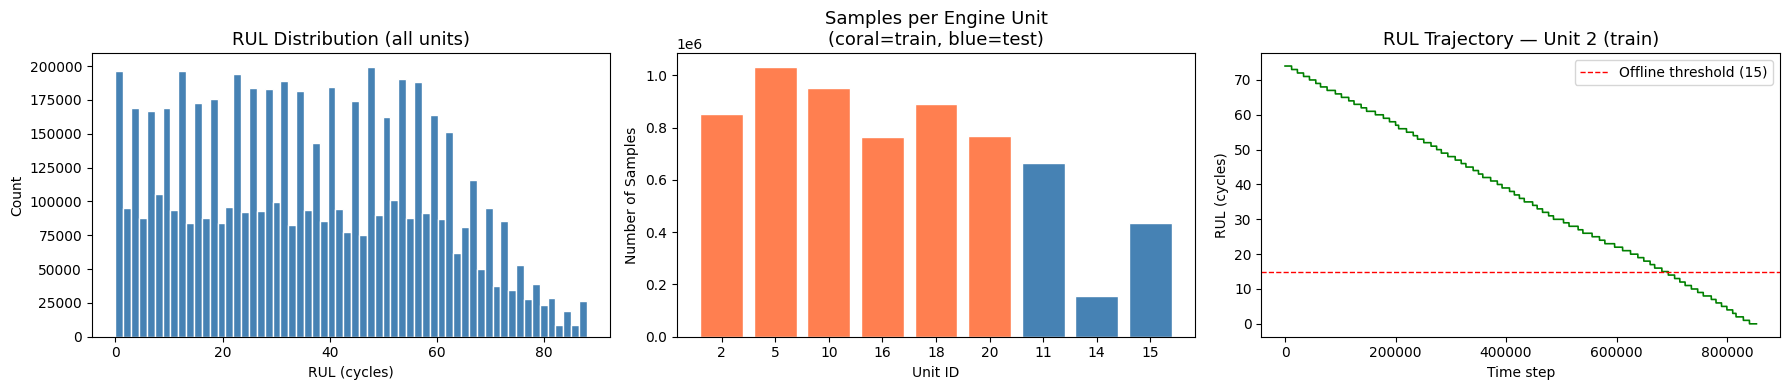

✅ EDA plots saved → eda_plots.png
[kgout 08:08:33] 📦 [CREATED] eda_plots.png
[kgout 08:08:35]    ↳ Uploaded to GDrive: eda_plots.png (id: 1yl4oqvWosq4KOEocumxjda7s46S8PQL1)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Combine train + test for the distribution plots
Y_all   = np.concatenate([Y_tr, Y_te], axis=0)
A_all   = np.concatenate([A_tr, A_te], axis=0)
unit_all = A_all[:, 0].astype(int)
unique_units_all = np.unique(unit_all)

# 1. RUL distribution (all units combined)
axes[0].hist(Y_all.flatten(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('RUL Distribution (all units)', fontsize=13)
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Count')

# 2. Samples per unit (train = coral, test = steelblue)
train_unit_ids = np.unique(A_tr[:, 0].astype(int))
test_unit_ids  = np.unique(A_te[:, 0].astype(int))
all_ids = np.concatenate([train_unit_ids, test_unit_ids])
colors  = ['coral'     if u in train_unit_ids else 'steelblue' for u in all_ids]
counts  = [np.sum(unit_all == u) for u in all_ids]
axes[1].bar([str(u) for u in all_ids], counts, color=colors, edgecolor='white')
axes[1].set_title('Samples per Engine Unit\n(coral=train, blue=test)', fontsize=13)
axes[1].set_xlabel('Unit ID')
axes[1].set_ylabel('Number of Samples')

# 3. RUL trajectory for first train unit
first_train_uid = int(train_unit_ids[0])
mask_traj = A_tr[:, 0].astype(int) == first_train_uid
axes[2].plot(Y_tr[mask_traj].flatten(), color='green', lw=1.2)
axes[2].axhline(15, color='red', ls='--', lw=1, label='Offline threshold (15)')
axes[2].set_title(f'RUL Trajectory — Unit {first_train_uid} (train)', fontsize=13)
axes[2].set_xlabel('Time step')
axes[2].set_ylabel('RUL (cycles)')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved → eda_plots.png")

---
## Cell 6 — Train/Test Split & Subsampling

In [6]:
SAMPLING = CONFIG["sampling"]

# ── The dev/test split is already done by the .h5 file ──────────────────────
# We don't need to re-split by unit IDs. Just subsample per-unit for memory.

def subsample_by_unit(W_, Xs_, Y_, A_, stride):
    if stride == 1:
        return W_, Xs_, Y_, A_
    ids = np.unique(A_[:, 0].astype(int))
    parts = [[], [], [], []]
    for uid in ids:
        m = A_[:, 0].astype(int) == uid
        parts[0].append(W_[m][::stride])
        parts[1].append(Xs_[m][::stride])
        parts[2].append(Y_[m][::stride])
        parts[3].append(A_[m][::stride])
    return tuple(np.concatenate(p) for p in parts)

W_tr, Xs_tr, Y_tr, A_tr = subsample_by_unit(W_tr, Xs_tr, Y_tr, A_tr, SAMPLING)
W_te, Xs_te, Y_te, A_te = subsample_by_unit(W_te, Xs_te, Y_te, A_te, SAMPLING)

print(f"After subsampling (stride={SAMPLING}):")
print(f"  Train: {len(W_tr):>8,} rows")
print(f"  Test : {len(W_te):>8,} rows")

# Concatenate W (4) + X_s (14) = 18 features
X_train_raw = np.concatenate([W_tr, Xs_tr], axis=1)
X_test_raw  = np.concatenate([W_te, Xs_te], axis=1)

print(f"\nX_train_raw : {X_train_raw.shape}")
print(f"X_test_raw  : {X_test_raw.shape}")
print(f"n_features  : {X_train_raw.shape[1]}  (should be 18)")

After subsampling (stride=1):
  Train: 5,263,447 rows
  Test : 1,253,743 rows

X_train_raw : (5263447, 18)
X_test_raw  : (1253743, 18)
n_features  : 18  (should be 18)


---
## Cell 7 — Normalisation (Min-Max, fit on train only)

In [7]:
scaler = MinMaxScaler(feature_range=(0.0, 1.0))
X_train_scaled = scaler.fit_transform(X_train_raw)   # fit on train
X_test_scaled  = scaler.transform(X_test_raw)        # apply to test (NO refit)

# ── Sanity check: clamp test values (edge cases where test exceeds train range)
X_test_scaled = np.clip(X_test_scaled, 0.0, 1.0)

print("Train scaled range: "
      f"min={X_train_scaled.min():.4f}  max={X_train_scaled.max():.4f}")
print("Test  scaled range: "
      f"min={X_test_scaled.min():.4f}  max={X_test_scaled.max():.4f}")

Train scaled range: min=0.0000  max=1.0000
Test  scaled range: min=0.0000  max=1.0000


---
## Cell 8 — Sliding Window Dataset

In [16]:
class NCMAPSSDataset(Dataset):
    """
    Builds (window_size, n_features) sliding windows PER UNIT,
    so window edges never bleed across unit boundaries.
    """
    def __init__(self, X_scaled, Y, A, window=50, stride=1):
        self.samples, self.labels = [], []
        unit_ids = np.unique(A[:, 0].astype(int))
        for uid in unit_ids:
            mask = A[:, 0].astype(int) == uid
            X_u = X_scaled[mask]
            Y_u = Y[mask]
            n = len(X_u)
            for i in range(0, n - window + 1, stride):
                self.samples.append(X_u[i : i + window])        # (window, 18)
                self.labels.append(Y_u[i + window - 1, 0])     # RUL at window end
        self.samples = np.array(self.samples, dtype=np.float32)  # (N, 50, 18)
        self.labels  = np.array(self.labels,  dtype=np.float32)  # (N,)
        print(f"  Unit IDs={list(unit_ids)}  →  "
              f"{len(self.samples):,} windows  "
              f"(shape={self.samples.shape})")

    def __len__(self):  return len(self.samples)
    def __getitem__(self, idx):
        return (torch.tensor(self.samples[idx]),
                torch.tensor(self.labels[idx]))


WINDOW = CONFIG["window"]
STRIDE = CONFIG["stride"]

print("Building train dataset:")
train_ds = NCMAPSSDataset(X_train_scaled, Y_tr, A_tr, WINDOW, STRIDE)
print("Building test  dataset:")
test_ds  = NCMAPSSDataset(X_test_scaled,  Y_te, A_te, WINDOW, STRIDE)

# ── Unit 14 trajectory check ──────────────────────────────────────────────────
uid14_mask = A_te[:, 0].astype(int) == 14
print(f"\nUnit 14 — total rows   : {uid14_mask.sum():,}")
print(f"Unit 14 — RUL range    : min={Y_te[uid14_mask].min():.1f}  max={Y_te[uid14_mask].max():.1f}")
print(f"Unit 14 — RUL mean     : {Y_te[uid14_mask].mean():.1f}")
print(f"Unit 11 — RUL mean     : {Y_te[A_te[:,0].astype(int)==11].mean():.1f}")
print(f"Unit 15 — RUL mean     : {Y_te[A_te[:,0].astype(int)==15].mean():.1f}")

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"] * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Verify tensor shapes from one batch
X_batch, Y_batch = next(iter(train_loader))
print(f"Batch shapes  : X={X_batch.shape}  Y={Y_batch.shape}")

Building train dataset:
  Unit IDs=[np.int64(2), np.int64(5), np.int64(10), np.int64(16), np.int64(18), np.int64(20)]  →  5,263,153 windows  (shape=(5263153, 50, 18))
Building test  dataset:
  Unit IDs=[np.int64(11), np.int64(14), np.int64(15)]  →  1,253,596 windows  (shape=(1253596, 50, 18))

Unit 14 — total rows   : 156,778
Unit 14 — RUL range    : min=0.0  max=75.0
Unit 14 — RUL mean     : 37.0
Unit 11 — RUL mean     : 29.0
Unit 15 — RUL mean     : 32.7

Train batches : 10280
Test  batches : 1225
Batch shapes  : X=torch.Size([512, 50, 18])  Y=torch.Size([512])


---
## Cell 9 — CNN-LSTM Model Architecture

In [9]:
class CNNLSTM_RUL(nn.Module):
    """
    1D-CNN extracts local temporal patterns across the 18 sensors.
    LSTM models the long-range degradation trajectory.
    Regression head outputs a single RUL float.
    """
    def __init__(self,
                 n_features   = 18,
                 window       = 50,
                 cnn_filters  = 64,
                 lstm_hidden  = 128,
                 lstm_layers  = 2,
                 dropout      = 0.3):
        super().__init__()

        # ── 1D-CNN Block ─────────────────────────────────────────────────────
        # Conv1d expects (Batch, Channels, Length)
        # We'll permute input from (B, W, F) → (B, F, W)
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, cnn_filters,     kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.Conv1d(cnn_filters, cnn_filters * 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        # After CNN:  (B, cnn_filters*2, window)  →  (B, 128, 50)

        # ── LSTM Block ────────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size  = cnn_filters * 2,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0.0,
        )

        # ── Regression Head ───────────────────────────────────────────────────
        self.regressor = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),          # → single RUL float
        )

    def forward(self, x):
        # x: (B, window=50, features=18)
        x = x.permute(0, 2, 1)           # → (B, 18, 50)   for Conv1d
        x = self.cnn(x)                   # → (B, 128, 50)
        x = x.permute(0, 2, 1)           # → (B, 50, 128)  for LSTM
        _, (h_n, _) = self.lstm(x)       # h_n: (num_layers, B, hidden)
        x = h_n[-1]                       # take last layer hidden state → (B, 128)
        return self.regressor(x).squeeze(-1)   # → (B,)


# ── Instantiate & verify ──────────────────────────────────────────────────────
model = CNNLSTM_RUL(
    n_features  = CONFIG["n_features"],
    window      = CONFIG["window"],
    cnn_filters = CONFIG["cnn_filters"],
    lstm_hidden = CONFIG["lstm_hidden"],
    lstm_layers = CONFIG["lstm_layers"],
    dropout     = CONFIG["dropout"],
).to(DEVICE)

# Dry-run sanity check
with torch.no_grad():
    dummy_in  = torch.randn(4, CONFIG["window"], CONFIG["n_features"]).to(DEVICE)
    dummy_out = model(dummy_in)
    print(f"Dry-run → input {tuple(dummy_in.shape)}  output {tuple(dummy_out.shape)}")
    assert dummy_out.shape == (4,), f"Expected (4,) got {dummy_out.shape}"

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print("\n✅ Model architecture verified")

Dry-run → input (4, 50, 18)  output (4,)
Trainable parameters: 301,121

✅ Model architecture verified


---
## Cell 10 — Loss, Optimiser, Scheduler

In [10]:
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    patience = CONFIG["lr_patience"],
    factor   = CONFIG["lr_factor"],
)

print(f"Criterion  : {criterion.__class__.__name__}")
print(f"Optimiser  : Adam  lr={CONFIG['lr']}")
print(f"Scheduler  : ReduceLROnPlateau  patience={CONFIG['lr_patience']}  factor={CONFIG['lr_factor']}")
print(f"Early stop : patience={CONFIG['patience']} epochs")

Criterion  : MSELoss
Optimiser  : Adam  lr=0.0002
Scheduler  : ReduceLROnPlateau  patience=8  factor=0.5
Early stop : patience=20 epochs


---
## Cell 11 — Training Loop

Key features:
- **Checkpoint every epoch** → safeguards against Kaggle session timeout
- **Best model** saved separately as `best_model.pt`
- **Early stopping** to avoid wasted epochs
- kgout auto-syncs every saved `.pt` file to Drive within 30 seconds

In [11]:
def compute_rmse(preds: np.ndarray, targets: np.ndarray) -> float:
    return float(np.sqrt(np.mean((preds - targets) ** 2)))


def compute_nasa_score(preds: np.ndarray, targets: np.ndarray) -> float:
    """
    NASA asymmetric scoring function.
    Late predictions (pred > true) are penalised more heavily than early ones.
    Lower is better. Score = Σ [ e^(d/13)-1 if d<0, or e^(d/10)-1 if d>=0 ]
    where d = pred - true.
    """
    d = preds - targets
    score = np.where(d < 0, np.exp(-d / 13.0) - 1, np.exp(d / 10.0) - 1)
    return float(np.sum(score))


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_b, Y_b in loader:
            X_b = X_b.to(device)
            pred = model(X_b).cpu().numpy()
            all_preds.append(pred)
            all_targets.append(Y_b.numpy())
    preds   = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)
    preds   = np.clip(preds, 0.0, None)   # RUL ≥ 0
    rmse    = compute_rmse(preds, targets)
    score   = compute_nasa_score(preds, targets)
    val_mse = float(np.mean((preds - targets) ** 2))
    return val_mse, rmse, score


# ── Training loop ─────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_rmse": [], "val_score": [], "lr": []}
best_val_loss  = float('inf')
epochs_no_improve = 0
CHECKPOINT_DIR = OUT_DIR   # /kaggle/working — watched by kgout

WARMUP_EPOCHS = 5                # ← ADD
base_lr = CONFIG['lr']

print(f"🚀 Starting training for up to {CONFIG['epochs']} epochs on {DEVICE}")
print(f"   Early stop patience : {CONFIG['patience']} epochs")
print(f"   Checkpoints saved to: {CHECKPOINT_DIR}")
print("-" * 70)

t_start = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    # ── LR Warmup ────────────────────────────────────────────────────────────
    if epoch <= WARMUP_EPOCHS:                                   # ← ADD
        warmup_lr = base_lr * (epoch / WARMUP_EPOCHS)           # ← ADD
        for pg in optimizer.param_groups:                        # ← ADD
            pg['lr'] = warmup_lr                                 # ← ADD
    
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for X_b, Y_b in train_loader:
        X_b, Y_b = X_b.to(DEVICE), Y_b.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = criterion(pred, Y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clip
        optimizer.step()
        running_loss += loss.item() * len(Y_b)

    train_loss = running_loss / len(train_ds)

    # ── Validate ─────────────────────────────────────────────────────────────
    val_mse, val_rmse, val_score = evaluate(model, test_loader, DEVICE)

    # ── Scheduler step ────────────────────────────────────────────────────────
    scheduler.step(val_mse)
    current_lr = optimizer.param_groups[0]['lr']

    # ── Log ───────────────────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_rmse"].append(val_rmse)
    history["val_score"].append(val_score)
    history["lr"].append(current_lr)

    elapsed = time.time() - t_start
    print(f"Epoch {epoch:>3d}/{CONFIG['epochs']}  "
          f"train_loss={train_loss:.4f}  "
          f"val_RMSE={val_rmse:.3f}  "
          f"NASA_score={val_score:.1f}  "
          f"lr={current_lr:.2e}  "
          f"[{elapsed/60:.1f}m]")

    # ── Save checkpoint every epoch (non-negotiable for Kaggle safety) ────────
    epoch_ckpt = {
        'epoch'                : epoch,
        'model_state_dict'     : model.state_dict(),
        'optimizer_state_dict' : optimizer.state_dict(),
        'val_mse'              : val_mse,
        'val_rmse'             : val_rmse,
        'val_score'            : val_score,
        'config'               : CONFIG,
        'history'              : history,
    }
    torch.save(epoch_ckpt, CHECKPOINT_DIR / 'latest_checkpoint.pt')

    # ── Save best model separately ────────────────────────────────────────────
    if val_mse < best_val_loss:
        best_val_loss = val_mse
        epochs_no_improve = 0
        torch.save(epoch_ckpt, CHECKPOINT_DIR / 'best_model.pt')
        joblib.dump(scaler, CHECKPOINT_DIR / 'scaler.pkl')   # ← ADD THIS
        print(f"          ✅ New best model saved  (val_RMSE={val_rmse:.3f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= CONFIG["patience"]:
            print(f"\n⏹  Early stopping triggered at epoch {epoch} "
                  f"(no improvement for {CONFIG['patience']} epochs)")
            break

total_time = time.time() - t_start
print(f"\n✅ Training complete in {total_time/60:.1f} minutes")
print(f"   Best val RMSE : {math.sqrt(best_val_loss):.3f}")

🚀 Starting training for up to 80 epochs on cuda
   Early stop patience : 20 epochs
   Checkpoints saved to: /kaggle/working
----------------------------------------------------------------------
Epoch   1/80  train_loss=300.6657  val_RMSE=7.101  NASA_score=874177.9  lr=4.00e-05  [0.9m]
          ✅ New best model saved  (val_RMSE=7.101)
[kgout 08:10:05] 📦 [CREATED] latest_checkpoint.pt
[kgout 08:10:06]    ↳ Uploaded to GDrive: latest_checkpoint.pt (id: 11CaVPqmiFnC75gDy-MPENrFKucwp4JD9)
[kgout 08:10:06] 📦 [CREATED] scaler.pkl
[kgout 08:10:07]    ↳ Uploaded to GDrive: scaler.pkl (id: 1wIJiV7MUEdJKHSYilWLqoabzGVc3gP14)
[kgout 08:10:07] 📦 [CREATED] best_model.pt
[kgout 08:10:08]    ↳ Uploaded to GDrive: best_model.pt (id: 1R2DuO66YZxZa8ZfEERWs8OWN9RjEEAgE)
Epoch   2/80  train_loss=83.7078  val_RMSE=8.741  NASA_score=1707490.1  lr=8.00e-05  [1.7m]
[kgout 08:11:08] 📦 [MODIFIED] latest_checkpoint.pt
[kgout 08:11:09]    ↳ Deleted old version: latest_checkpoint.pt
[kgout 08:11:10]    ↳ Uploaded

---
## Cell 12 — Training Curves

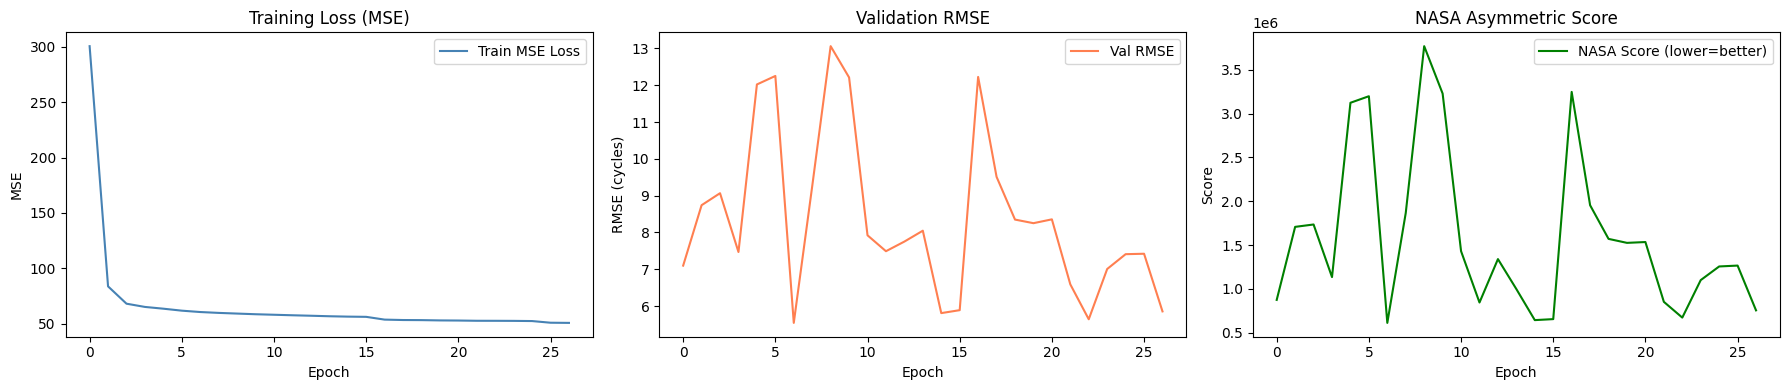

✅ training_curves.png saved
[kgout 08:34:35] 📦 [MODIFIED] training_curves.png
[kgout 08:34:35]    ↳ Deleted old version: training_curves.png
[kgout 08:34:36]    ↳ Uploaded to GDrive: training_curves.png (id: 1XbeoAgP0coMFJcXUvBHiIGxz3OfqhxW_)


In [14]:
epochs_ran = len(history["train_loss"])
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["train_loss"], label='Train MSE Loss', color='steelblue')
axes[0].set_title('Training Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history["val_rmse"], label='Val RMSE', color='coral')
axes[1].set_title('Validation RMSE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (cycles)')
axes[1].legend()

axes[2].plot(history["val_score"], label='NASA Score (lower=better)', color='green')
axes[2].set_title('NASA Asymmetric Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Score')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ training_curves.png saved")

---
## Cell 13 — Final Evaluation on Test Units

  FINAL TEST METRICS (Best Model)
  RMSE        : 5.546 cycles
  MAE         : 3.926 cycles
  NASA Score  : 611799.1  (lower is better)

  PER-UNIT TEST RMSE:
--------------------------------------------------
  Unit 11  : RMSE = 4.268  (663,446 windows)
  Unit 14  : RMSE = 8.445  (156,729 windows)
  Unit 15  : RMSE = 5.940  (433,421 windows)
--------------------------------------------------


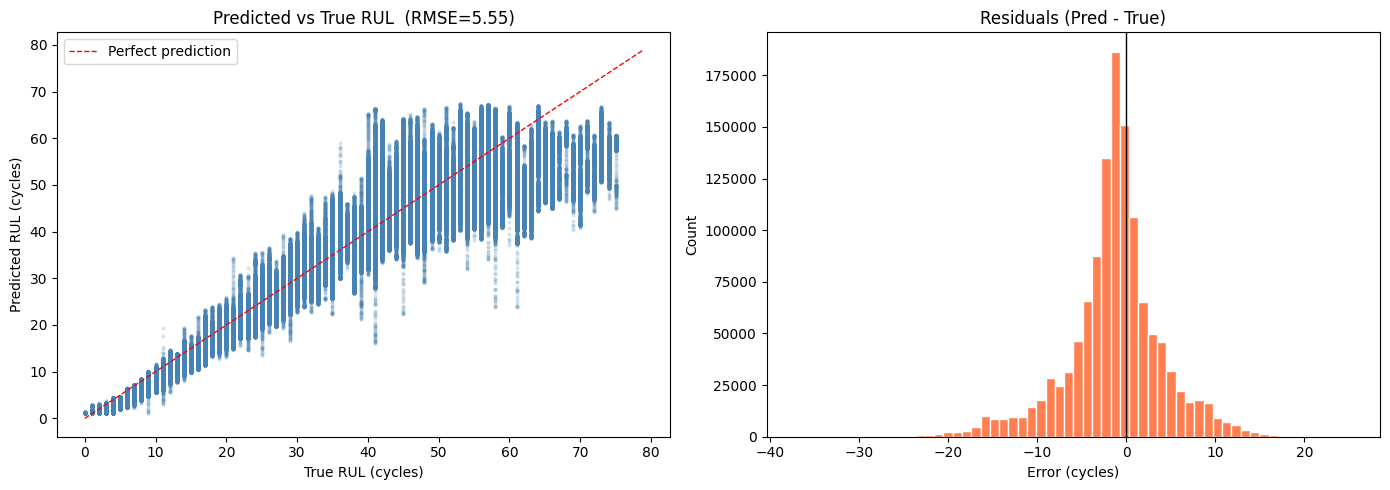

✅ test_evaluation.png saved
[kgout 08:35:36] 📦 [MODIFIED] test_evaluation.png
[kgout 08:35:37]    ↳ Deleted old version: test_evaluation.png
[kgout 08:35:38]    ↳ Uploaded to GDrive: test_evaluation.png (id: 1zR6SC2LAxWe5khgmOZcyQs8JAUWKhkC-)


In [15]:
# Load best model weights for final eval
best_ckpt = torch.load(OUT_DIR / 'best_model.pt', map_location=DEVICE)
model.load_state_dict(best_ckpt['model_state_dict'])
model.eval()

# ── Collect per-unit predictions ──────────────────────────────────────────────
all_preds, all_targets = [], []
with torch.no_grad():
    for X_b, Y_b in test_loader:
        pred = model(X_b.to(DEVICE)).cpu().numpy()
        all_preds.append(np.clip(pred, 0.0, None))
        all_targets.append(Y_b.numpy())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

final_rmse  = compute_rmse(all_preds, all_targets)
final_score = compute_nasa_score(all_preds, all_targets)
final_mae   = float(np.mean(np.abs(all_preds - all_targets)))

print("=" * 50)
print("  FINAL TEST METRICS (Best Model)")
print("=" * 50)
print(f"  RMSE        : {final_rmse:.3f} cycles")
print(f"  MAE         : {final_mae:.3f} cycles")
print(f"  NASA Score  : {final_score:.1f}  (lower is better)")
print("=" * 50)

print("\n  PER-UNIT TEST RMSE:")
print("-" * 50)

# Rebuild per-unit predictions from test_ds
# (test_ds preserves unit order since NCMAPSSDataset iterates units in sorted order)
unit_cursor = 0
test_unit_ids_sorted = sorted(CONFIG['test_units'])
for uid in test_unit_ids_sorted:
    mask_uid = A_te[:, 0].astype(int) == uid
    # Count windows for this unit (same formula as NCMAPSSDataset)
    n_uid = int(mask_uid.sum())
    n_windows_uid = max(0, n_uid - CONFIG['window'] + 1)
    preds_uid   = all_preds[unit_cursor : unit_cursor + n_windows_uid]
    targets_uid = all_targets[unit_cursor : unit_cursor + n_windows_uid]
    unit_cursor += n_windows_uid
    if len(preds_uid) == 0:
        print(f"  Unit {uid:<4}: no windows")
        continue
    rmse_uid = compute_rmse(preds_uid, targets_uid)
    print(f"  Unit {uid:<4}: RMSE = {rmse_uid:.3f}  ({len(preds_uid):,} windows)")

print("-" * 50)

# ── Prediction scatter ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_targets, all_preds, alpha=0.15, s=4, color='steelblue')
lims = [0, max(all_targets.max(), all_preds.max()) * 1.05]
axes[0].plot(lims, lims, 'r--', lw=1, label='Perfect prediction')
axes[0].set_xlabel('True RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].set_title(f'Predicted vs True RUL  (RMSE={final_rmse:.2f})')
axes[0].legend()

axes[1].hist(all_preds - all_targets, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Residuals (Pred - True)')
axes[1].set_xlabel('Error (cycles)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUT_DIR / 'test_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ test_evaluation.png saved")

---
## Cell 14 — Export `inference.py`

This is the contract file that Teams 2 and 3 will import. It is saved directly to `/kaggle/working/` so kgout auto-syncs it to Drive.

In [17]:
INFERENCE_CODE = '''
# dl_engine/inference.py
# ─────────────────────────────────────────────────────────────────────────────
# CONTRACT FILE — this is the ONLY file other teams import.
# Public API: predict_rul(sensor_tensor: np.ndarray) -> float
# ─────────────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import numpy as np
import joblib
from pathlib import Path

# ── Model definition (must match training) ────────────────────────────────────
class CNNLSTM_RUL(nn.Module):
    def __init__(self, n_features=18, window=50, cnn_filters=64,
                 lstm_hidden=128, lstm_layers=2, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, cnn_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters),
            nn.ReLU(),
            nn.Conv1d(cnn_filters, cnn_filters * 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_filters * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size  = cnn_filters * 2,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0.0,
        )
        self.regressor = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]
        return self.regressor(x).squeeze(-1)


# ── Lazy-loaded singletons ────────────────────────────────────────────────────
_model  = None
_scaler = None


def load_model(
    weights_path: str = "dl_engine/weights/best_model.pt",
    scaler_path : str = "dl_engine/weights/scaler.pkl",
):
    """Load model weights and scaler. Called automatically on first predict_rul()."""
    global _model, _scaler

    checkpoint = torch.load(weights_path, map_location="cpu")  # CPU-safe on GTX 1650
    cfg = checkpoint.get("config", {})

    _model = CNNLSTM_RUL(
        n_features  = cfg.get("n_features",  18),
        window      = cfg.get("window",      50),
        cnn_filters = cfg.get("cnn_filters", 64),
        lstm_hidden = cfg.get("lstm_hidden", 128),
        lstm_layers = cfg.get("lstm_layers", 2),
        dropout     = cfg.get("dropout",     0.3),
    )
    _model.load_state_dict(checkpoint["model_state_dict"])
    _model.eval()
    _scaler = joblib.load(scaler_path)
    print(f"[inference.py] Model loaded from {weights_path}  "
          f"(best epoch={checkpoint.get('epoch','?')}  "
          f"val_RMSE={checkpoint.get('val_rmse', float('nan')):.3f})")


def predict_rul(sensor_tensor: np.ndarray) -> float:
    """
    Predict Remaining Useful Life for a single window of sensor data.

    Parameters
    ----------
    sensor_tensor : np.ndarray, shape (50, 18)
        One sliding window — 50 time-steps × 18 features
        (4 operating conditions + 14 physical sensors), RAW (unscaled).
        The scaler is applied internally.

    Returns
    -------
    float
        Predicted RUL in production shift-cycles. Always >= 0.
    """
    if _model is None:
        load_model()

    assert sensor_tensor.shape == (50, 18), (
        f"predict_rul expects shape (50, 18), got {sensor_tensor.shape}"
    )

    scaled = _scaler.transform(sensor_tensor.astype(np.float32))  # (50, 18)
    scaled = np.clip(scaled, 0.0, 1.0)
    t = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0)    # (1, 50, 18)

    with torch.no_grad():
        rul = _model(t).item()

    return max(0.0, rul)
'''

inference_path = OUT_DIR / 'inference.py'
with open(inference_path, 'w') as f:
    f.write(INFERENCE_CODE.strip())

print(f"✅ inference.py written to {inference_path}")
print("   kgout will auto-sync this to Google Drive.")
print("   Teams 2 & 3 copy this file to dl_engine/ and call predict_rul().")

✅ inference.py written to /kaggle/working/inference.py
   kgout will auto-sync this to Google Drive.
   Teams 2 & 3 copy this file to dl_engine/ and call predict_rul().


---
## Cell 15 — Verify All Output Files

In [18]:
import os

required_files = [
    'best_model.pt',
    'latest_checkpoint.pt',
    'scaler.pkl',
    'inference.py',
    'training_curves.png',
    'test_evaluation.png',
    'eda_plots.png',
]

print(f"📁 Files in /kaggle/working/:")
print("-" * 50)
all_good = True
for fname in required_files:
    fpath = OUT_DIR / fname
    if fpath.exists():
        size_kb = fpath.stat().st_size / 1024
        print(f"  ✅  {fname:<30s}  ({size_kb:>8.1f} KB)")
    else:
        print(f"  ❌  {fname:<30s}  MISSING")
        all_good = False

print("-" * 50)
if all_good:
    print("✅ All required output files are present.")
    print("   kgout is syncing them to Google Drive.")
    print("\n📋 Next steps:")
    print("   1. Wait ~60s for kgout to complete the final sync.")
    print("   2. Download best_model.pt + scaler.pkl from Drive.")
    print("   3. Copy both files → dl_engine/weights/ in the repo.")
    print("   4. Copy inference.py → dl_engine/inference.py in the repo.")
    print("   5. Update the import path at the top of inference.py if needed.")
else:
    print("❌ Some files are missing — check the cells above for errors.")

📁 Files in /kaggle/working/:
--------------------------------------------------
  ✅  best_model.pt                   (  3555.4 KB)
  ✅  latest_checkpoint.pt            (  3556.6 KB)
  ✅  scaler.pkl                      (     1.0 KB)
  ✅  inference.py                    (     4.1 KB)
  ✅  training_curves.png             (    99.9 KB)
  ✅  test_evaluation.png             (    90.3 KB)
  ✅  eda_plots.png                   (    70.2 KB)
--------------------------------------------------
✅ All required output files are present.
   kgout is syncing them to Google Drive.

📋 Next steps:
   1. Wait ~60s for kgout to complete the final sync.
   2. Download best_model.pt + scaler.pkl from Drive.
   3. Copy both files → dl_engine/weights/ in the repo.
   4. Copy inference.py → dl_engine/inference.py in the repo.
   5. Update the import path at the top of inference.py if needed.


---
## Cell 16 — Quick Inference Smoke Test

Validates that `predict_rul()` works end-to-end with the saved weights, exactly as Teams 2 & 3 will call it.

In [19]:
# ── Simulate what other teams will do: load inference.py and call predict_rul ─
import importlib.util, sys

spec   = importlib.util.spec_from_file_location("inference", OUT_DIR / "inference.py")
inf_mod = importlib.util.module_from_spec(spec)
sys.modules["inference"] = inf_mod
spec.loader.exec_module(inf_mod)

# Load with explicit paths pointing to /kaggle/working/
inf_mod.load_model(
    weights_path = str(OUT_DIR / 'best_model.pt'),
    scaler_path  = str(OUT_DIR / 'scaler.pkl'),
)

# Grab a real test window (last 50 rows of first test unit)
test_uid = CONFIG['test_units'][0]
mask_te  = A_te[:, 0].astype(int) == test_uid
X_sample = np.concatenate([W_te[mask_te], Xs_te[mask_te]], axis=1)  # (N, 18) — RAW
window   = X_sample[-50:]   # last 50 steps → most degraded, should be low RUL
true_rul = float(Y_te[mask_te][-1, 0])

predicted_rul = inf_mod.predict_rul(window)

print(f"\n🧪 Smoke test — unit {test_uid} (end of life):")
print(f"   True RUL      : {true_rul:.1f} cycles")
print(f"   Predicted RUL : {predicted_rul:.1f} cycles")
print(f"   Error         : {abs(predicted_rul - true_rul):.1f} cycles")

# Also test a healthy window (first 50 rows) — should be high RUL
window_healthy  = X_sample[:50]
true_rul_healthy = float(Y_te[mask_te][49, 0])
pred_rul_healthy = inf_mod.predict_rul(window_healthy)
print(f"\n   Healthy window (start of life):")
print(f"   True RUL      : {true_rul_healthy:.1f} cycles")
print(f"   Predicted RUL : {pred_rul_healthy:.1f} cycles")

print("\n✅ Smoke test passed — predict_rul() is working correctly")

[inference.py] Model loaded from /kaggle/working/best_model.pt  (best epoch=7  val_RMSE=5.546)

🧪 Smoke test — unit 11 (end of life):
   True RUL      : 0.0 cycles
   Predicted RUL : 1.2 cycles
   Error         : 1.2 cycles

   Healthy window (start of life):
   True RUL      : 58.0 cycles
   Predicted RUL : 64.8 cycles

✅ Smoke test passed — predict_rul() is working correctly
[kgout 08:40:38] 📦 [CREATED] inference.py
[kgout 08:40:40]    ↳ Uploaded to GDrive: inference.py (id: 1yZw-fvWCvrqSbJ8iLndCOxU--dUDTTbq)


---
## Cell 17 — Final Summary & kgout Flush

In [20]:
import time

best_ckpt = torch.load(OUT_DIR / 'best_model.pt', map_location='cpu')

print("=" * 60)
print("  MIOM CAPSTONE — DL ENGINE TRAINING SUMMARY")
print("=" * 60)
print(f"  Dataset         : N-CMAPSS DS02")
print(f"  Sampling rate   : 1 sample / {CONFIG['sampling']}s")
print(f"  Train units     : {CONFIG['train_units']}")
print(f"  Test  units     : {CONFIG['test_units']}")
print(f"  Window size     : {CONFIG['window']} steps")
print(f"  Features        : {CONFIG['n_features']} (W×4 + Xs×14)")
print(f"  Best epoch      : {best_ckpt['epoch']}")
print(f"  Best val RMSE   : {best_ckpt['val_rmse']:.3f} cycles")
print(f"  Best NASA Score : {best_ckpt['val_score']:.1f}")
print(f"  Total epochs    : {len(history['train_loss'])}")
print("=" * 60)
print("  OUTPUT FILES (syncing to Google Drive via kgout):")
for f in ['best_model.pt', 'latest_checkpoint.pt', 'scaler.pkl', 'inference.py']:
    fpath = OUT_DIR / f
    if fpath.exists():
        print(f"    ✅  {f}  ({fpath.stat().st_size/1024:.0f} KB)")
print("=" * 60)

print("\n⏳ Waiting 60s for kgout to complete final Drive sync...")
time.sleep(60)
print("✅ Done. Check your Google Drive folder for all output files.")

# Explicitly stop kgout after the sleep
try:
    kg.stop()
    print("✅ kgout stopped cleanly.")
except Exception as e:
    print(f"kgout stop: {e}")

  MIOM CAPSTONE — DL ENGINE TRAINING SUMMARY
  Dataset         : N-CMAPSS DS02
  Sampling rate   : 1 sample / 1s
  Train units     : [2, 5, 10, 16, 18, 20]
  Test  units     : [11, 14, 15]
  Window size     : 50 steps
  Features        : 18 (W×4 + Xs×14)
  Best epoch      : 7
  Best val RMSE   : 5.546 cycles
  Best NASA Score : 611799.1
  Total epochs    : 27
  OUTPUT FILES (syncing to Google Drive via kgout):
    ✅  best_model.pt  (3555 KB)
    ✅  latest_checkpoint.pt  (3557 KB)
    ✅  scaler.pkl  (1 KB)
    ✅  inference.py  (4 KB)

⏳ Waiting 60s for kgout to complete final Drive sync...
✅ Done. Check your Google Drive folder for all output files.
[kgout 08:41:48] 🛑 kgout stopped.
✅ kgout stopped cleanly.
